<a href="https://colab.research.google.com/github/ogut77/DataScience/blob/main/Homework7V5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The definition of the variables used in the Bookbinder dataset is given below. Use choice variable as dependent variable.

Choice: Whether the customer purchased the The Art History of Florence. 1 corresponds to a purchase and 0 corresponds to a nonpurchase.

Gender: 0 = Female and 1 = Male.

Amount purchased: Total money spent on BBBC books.

Frequency: Total number of purchases in the chosen period (used as a proxy for frequency.)

Last purchase (recency of purchase): Months since last purchase.

First purchase: Months since first purchase.

P_Child: Number of children’s books purchased.

P_Youth: Number of youth books purchased.

P_Cook: Number of cookbooks purchased.

P_DIY: Number of do-it-yourself books purchased.

P_Art: Number of art books purchased.


In [1]:

import pandas as pd
import numpy as np
df = pd.read_excel('https://hogut.weebly.com/uploads/1/8/1/6/18163409/bookbinder2.xls')
df.head()

,Gender,Amount purchased,Frequency,Last purchase,First purchase,P_Child,P_Youth,P_Cook,P_DIY,P_Art,Staus,Choice
0,1,113,8,1,8,0,1,0,0,0,Training,Y
1,1,418,6,11,66,0,2,3,2,3,Training,Y
2,1,336,18,6,32,2,0,1,1,2,Training,Y
3,1,180,16,5,42,2,0,0,1,1,Training,Y
4,0,320,2,3,18,0,0,0,1,2,Training,Y


In [2]:
# Using dataframe df: convert choice to 0(N)and 1(Y)

# Convert 'Choice' column to numerical values (0 for 'N', 1 for 'Y')
df['Choice'] = df['Choice'].map({'N': 0, 'Y': 1})
 #Using dataframe df: Use choice variable as dependent variable.
 #Construct training data and test data  when the status variables having  Training and  Test value.

import pandas as pd
from sklearn.linear_model import LogisticRegression

# Assuming 'df' is your DataFrame
# Filter the DataFrame for training data
training_data = df[df['Staus'] == 'Training']
test_data = df[df['Staus'] == 'Test']
# Define features (X) and target variable (y)
X_train = training_data[['Gender', 'Amount purchased', 'Frequency', 'Last purchase', 'First purchase', 'P_Child', 'P_Youth', 'P_Cook', 'P_DIY', 'P_Art']]
y_train = training_data['Choice']
X_test = test_data[['Gender', 'Amount purchased', 'Frequency', 'Last purchase', 'First purchase', 'P_Child', 'P_Youth', 'P_Cook', 'P_DIY', 'P_Art']]
y_test = test_data['Choice']


In [4]:
#Q1(25 pt)-Using logistic regression model in train data,
#a)	In the model, test that the claim that the coefficients of independent variables are different than 0 at the 5% significance level.
#b)	Which variables that is significantly different than 0 increase or decrease the probability of Choice=Yes?

import statsmodels.api as sm
X_train_sm = sm.add_constant(X_train)
log_reg_sm = sm.Logit(y_train, X_train_sm).fit()
print(log_reg_sm.summary())

#a) Based on the p-values ($P>|z|$), the following variables are statistically significant as their p-values are less than 0.05:
# Gender, Amount purchased, Frequency, Last purchase, P_Child, P_Youth, P_Cook, P_DIY, and P_Art. The variable First purchase ($p=0.248$) is not significant.

#b) Impact on Choice (Probability of Purchase):
#Increase Probability (Positive Coefficients): * P_Art (+0.6861): Previous art book purchases are the strongest predictor of buying this book.
#Last purchase (+0.6118): More months since the last purchase correlates with a higher probability.
#Amount purchased (+0.0019): Higher total spend slightly increases likelihood.

#Decrease Probability (Negative Coefficients):
#Gender (-0.8632): Males (1) are less likely to buy than females (0).
#P_Cook, P_DIY, P_Child, P_Youth: High volume in these unrelated categories significantly lowers the likelihood.
#Frequency (-0.0755): More frequent past buyers are less likely to purchase this specific title.

Optimization terminated successfully.
         Current function value: 0.435050
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 Choice   No. Observations:                 1600
Model:                          Logit   Df Residuals:                     1589
Method:                           MLE   Df Model:                           10
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.2264
Time:                        05:05:45   Log-Likelihood:                -696.08
converged:                       True   LL-Null:                       -899.74
Covariance Type:            nonrobust   LLR p-value:                 2.612e-81
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.3515      0.214     -1.640      0.101      -0.772       0.069
Gender     

In [5]:
#Q2(15 pt)-Using knn model in train data(choose k based on CV),
#get the performance metric on test data(accuracy,recall, precision confusion matrix). What is the k value chosen based on k?

from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Grid Search for k from 1 to 30
param_grid = {'n_neighbors': list(range(1, 31))}
knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')

# Model fit
knn_cv.fit(X_train_scaled, y_train)

# Best K
best_k = knn_cv.best_params_['n_neighbors']
print(f"The best k value chosen based on CV is: {best_k}")

# Test data predictions
best_knn = knn_cv.best_estimator_
y_pred_knn = best_knn.predict(X_test_scaled)

# Results
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_knn):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

# The optimal model was found at k = 23, achieving a high overall accuracy of 89.83%.
# However, the low recall (25.49%) and precision (38.81%) indicate the model struggles to correctly identify actual buyers, as shown by the 152 false negatives in the confusion matrix.

The best k value chosen based on CV is: 23
Accuracy: 0.8983
Precision: 0.3881
Recall: 0.2549
Confusion Matrix:
[[2014   82]
 [ 152   52]]


In [6]:
#Q3(35 pt)-Get the performance metric on test data (accuracy,recall, precision, confsuion matrix area under curve(auc)) using
#Logistic regression,naive bayes, Multi layer perceptor(MLP) and SVM, ligtGBM and kNN with optimized parameter in Q2.
#Report which methods performs best on these metrics?

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": GaussianNB(),
    "MLP (Neural Network)": MLPClassifier(max_iter=1000, random_state=42),
    "SVM": SVC(probability=True, random_state=42), # probability=True needed for AUC
    "LightGBM": LGBMClassifier(random_state=42),
    "Optimized KNN": best_knn # Using the model from Q2
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1] # Get probabilities for class 1

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "AUC": auc,
        "Confusion Matrix": str(cm.tolist())
    })

# Results
results_df = pd.DataFrame(results)
display(results_df)

# SVM and Optimized KNN achieved the highest overall accuracies (approx. 90%), but Logistic Regression is the best performing model overall due to its superior
# balance of Precision (37.7%), Recall (37.7%), and the highest AUC (0.80). While models like SVM have fewer false positives,
# Logistic Regression's higher AUC indicates it is more effective at distinguishing between buyers and non-buyers across the dataset.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[LightGBM] [Info] Number of positive: 400, number of negative: 1200
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000411 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 367
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.250000 -> initscore=-1.098612
[LightGBM] [Info] Start training from score -1.098612


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Accuracy,Precision,Recall,AUC,Confusion Matrix
0,Logistic Regression,0.889565,0.377451,0.377451,0.800695,"[[1969, 127], [127, 77]]"
1,Naive Bayes,0.848261,0.232472,0.308824,0.744416,"[[1888, 208], [141, 63]]"
2,MLP (Neural Network),0.863043,0.287356,0.367647,0.766964,"[[1910, 186], [129, 75]]"
3,SVM,0.902609,0.418033,0.250000,0.779261,"[[2025, 71], [153, 51]]"
4,LightGBM,0.853478,0.266667,0.372549,0.766639,"[[1887, 209], [128, 76]]"
5,Optimized KNN,0.898261,0.388060,0.254902,0.778915,"[[2014, 82], [152, 52]]"


Optimal Probability Threshold for Targeting: 0.18
Number of Customers to Target in Test Data: 944
Maximum Expected Profit on Test Data: $1036.40


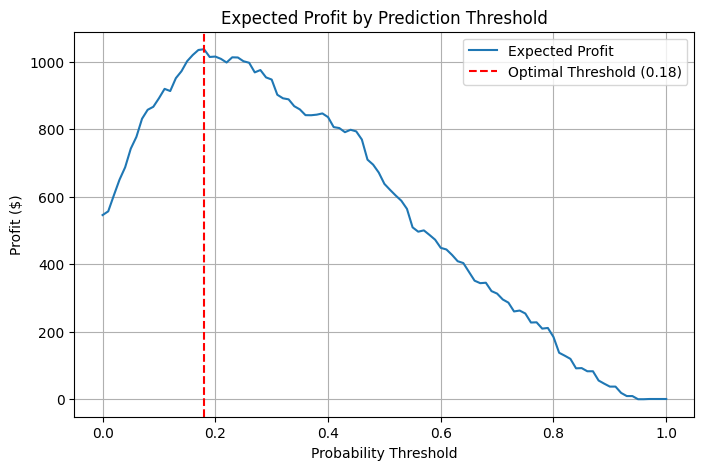

In [7]:
#Q4(25 pt)-There is a need to evaluate the effectiveness of the current direct mail program and assess whether predictive modeling
#can be leveraged to enhance targeting and increase response rates.
# Assume that you make profit of 10 $ by selling a book and the cost of sending mail is 0.65 $.
# Based on the logistic model, which customers should Bookbinders target on test data?
#What is the expected profits if these customers are targeted?
#Hint :
#To evaluate the direct mail program, use an ROC curve to assess the logistic model’s ability to predict buyers.
#The curve plots True Positive Rate vs. False Positive Rate, and a high AUC shows the model is effective.
# To decide who to target, calculate profit for different probability thresholds:
# Profit = (True Positives × $9.35) - (False Positives × $0.65).
#True positive profit is $93.5 becuase revenue is $10 and there is a $0.65 cost of sending mail.
#Bookbinders should target customers with probabilities above the threshold that maximizes profit,
# improving targeting and response rates compared to the current program

import numpy as np
import matplotlib.pyplot as plt

# Logistic Regression on training data
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Probabilities for the test set
y_proba_test = log_reg.predict_proba(X_test_scaled)[:, 1]

# Variables to store optimization results
thresholds = np.arange(0.0, 1.01, 0.01)
max_profit = -np.inf
best_threshold = 0.0
best_target_count = 0

profits = []

# Maximum profit
for t in thresholds:
    # Predict 1 if probability >= threshold, else 0
    y_pred_t = (y_proba_test >= t).astype(int)

    # TP and FP
    TP = np.sum((y_pred_t == 1) & (y_test == 1))
    FP = np.sum((y_pred_t == 1) & (y_test == 0))

    # Profit according to the prompt's formula
    profit = (TP * 9.35) - (FP * 0.65)
    profits.append(profit)

    # Update max profit
    if profit > max_profit:
        max_profit = profit
        best_threshold = t
        best_target_count = np.sum(y_pred_t)

print(f"Optimal Probability Threshold for Targeting: {best_threshold:.2f}")
print(f"Number of Customers to Target in Test Data: {best_target_count}")
print(f"Maximum Expected Profit on Test Data: ${max_profit:.2f}")

# Optional: Plot Profit vs. Threshold for visual confirmation
plt.figure(figsize=(8, 5))
plt.plot(thresholds, profits, label="Expected Profit")
plt.axvline(x=best_threshold, color='r', linestyle='--', label=f"Optimal Threshold ({best_threshold:.2f})")
plt.title("Expected Profit by Prediction Threshold")
plt.xlabel("Probability Threshold")
plt.ylabel("Profit ($)")
plt.legend()
plt.grid(True)
plt.show()

# Based on the profit optimization analysis, Bookbinders should target all customers in the test set who have a predicted purchase probability of 0.18 or higher.
# By using this optimal threshold, the company would target 944 customers, resulting in a maximum expected profit of $1,036.40.
# This strategy balances the $9.35 profit from true positives against the $0.65 loss from false positives,
# significantly improving the effectiveness of the direct mail program compared to a standard 0.50 threshold.